In [17]:
import pandas as pd
import os
import re
import matplotlib.pyplot as plt

from Bio import SeqIO
from Bio.Seq import Seq


In [5]:
def extract_attribute(attr_string, key="product"):
    # parsing gtf attributes with regex
    match = re.search(rf'{key}=([^;]+)', attr_string)
    return match.group(1) if match else None

def read_annotation_table(ref_gtf, annot_type='CDS'):
    # read the gtf table
    annot = pd.read_csv(ref_gtf, sep="\t", skiprows=3, 
                        names=['ref', 'source', 'type', 'start', 'end', 'useless_col', 'strand', 'useless2', 'annotation'],
                       index_col=None)
    # only keep the CDS annotations
    annot_CDS = annot[annot.type==annot_type][['ref', 'type', 'start', 'end', 'strand', 'annotation']].reset_index()
    # add the gene product annotation
    annot_CDS['product'] = annot_CDS.apply(lambda x: extract_attribute(x['annotation']),
                                                axis=1)
    annot_CDS['locus_tag'] = annot_CDS.apply(lambda x: extract_attribute(x['annotation'], key='locus_tag'),
                                                axis=1)
    annot_CDS['gene'] = annot_CDS.apply(lambda x: extract_attribute(x['annotation'], key='gene'),
                                                axis=1)
    return annot_CDS


We have previously identified mutations that are specific to the adapted strain. Here we aggregate the results over multiple antibiotics and take a closer look. 

In [6]:
# antibiotics we have analyzed
abx = ['CIP', 'KAN', 'PEN', 'RIF', 'VNC']

# column headers for bed files
cols = ["chrom","start", "end", "ref", "alt", "qual"]

gff = read_annotation_table("../refs/GCF_040687945.1_ASM4068794v1_genomic.gff",
                           annot_type='gene')
ref_fasta = "../refs//GCF_040687945.1_ASM4068794v1_genomic.fna"
ref_chrom = "NZ_CP155539.1"

variant_all = pd.DataFrame()
for ab in abx:
    variant_file = f"data/vars/variant_calling_{ab}/adapted_unique/0000.bed"
    variant_abx = pd.read_csv(variant_file, header=None, sep='\t', names=cols)
    variant_abx['ABX'] = ab
    variant_all = pd.concat([variant_all, variant_abx], axis=0)
variant_all.shape

(65, 7)

In [7]:
merged = variant_all.merge(
    gff[["ref", "start", "end", "strand","gene", "locus_tag"]],
    left_on="chrom", right_on="ref",
    how="left"
)

merged["in_gene"] = merged.apply(lambda row: row["start_x"] >= row["start_y"] and row["end_x"] <= row["end_y"], axis=1)

# mutations in annotated genes
genic_mutations = merged[merged.in_gene]
genic_mutations.rename(columns={'start_x':'start',
                               'end_x':'end',
                               'start_y':'gene_start',
                               'end_y': 'gene_end', 
                                'ref_x':'ref'}, inplace = True)
genic_mutations.drop(columns=['ref_y', 'in_gene'], inplace=True)

/tmp/ipykernel_1877/3130726552.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  genic_mutations.rename(columns={'start_x':'start',
/tmp/ipykernel_1877/3130726552.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  genic_mutations.drop(columns=['ref_y', 'in_gene'], inplace=True)


In [8]:
genic_mutations.shape

(29, 12)

In [9]:

CODON_TABLE = {
    # Standard genetic code
    'TTT':'F','TTC':'F','TTA':'L','TTG':'L',
    'CTT':'L','CTC':'L','CTA':'L','CTG':'L',
    'ATT':'I','ATC':'I','ATA':'I','ATG':'M',
    'GTT':'V','GTC':'V','GTA':'V','GTG':'V',
    'TCT':'S','TCC':'S','TCA':'S','TCG':'S',
    'CCT':'P','CCC':'P','CCA':'P','CCG':'P',
    'ACT':'T','ACC':'T','ACA':'T','ACG':'T',
    'GCT':'A','GCC':'A','GCA':'A','GCG':'A',
    'TAT':'Y','TAC':'Y','TAA':'*','TAG':'*',
    'CAT':'H','CAC':'H','CAA':'Q','CAG':'Q',
    'AAT':'N','AAC':'N','AAA':'K','AAG':'K',
    'GAT':'D','GAC':'D','GAA':'E','GAG':'E',
    'TGT':'C','TGC':'C','TGA':'*','TGG':'W',
    'CGT':'R','CGC':'R','CGA':'R','CGG':'R',
    'AGT':'S','AGC':'S','AGA':'R','AGG':'R',
    'GGT':'G','GGC':'G','GGA':'G','GGG':'G'
}

def nuc_complement(nucleotide):
    if len(nucleotide)>1:
        return(None)
    complements = {'A': 'T', 'C': 'G',
                  'G':'C', 'T':'A'}
    return(complements[nucleotide])

def extract_cds_sequence(
    cds_start,
    cds_end,
    strand,
    fasta_path = ref_fasta,
    chrom = ref_chrom,
):
    """
    Extract CDS sequence from a reference FASTA.

    Parameters
    ----------
    fasta_path : str
        Path to reference FASTA
    chrom : str
        Contig / chromosome ID (must match FASTA header)
    cds_start : int
        CDS start (1-based, inclusive)
    cds_end : int
        CDS end (1-based, inclusive)
    strand : str
        '+' or '-'

    Returns
    -------
    str
        CDS sequence in 5'→3' coding orientation
    """

    if strand not in ('+', '-'):
        raise ValueError("strand must be '+' or '-'")

    # Load reference sequence
    for record in SeqIO.parse(fasta_path, "fasta"):
        if record.id == chrom:
            ref_seq = record.seq
            break
    else:
        raise ValueError(f"Chromosome {chrom} not found in FASTA")

    # Convert to 0-based slicing
    subseq = ref_seq[cds_start - 1 : cds_end]

    if strand == '-':
        subseq = subseq.reverse_complement()

    return str(subseq).upper()

def annotate_aa_change(
    var_pos,
    ref_base,
    alt_base,
    cds_start,
    cds_end,
    strand
):
    """
    Annotate an SNV as an amino acid change (e.g. S81Y).

    Parameters
    ----------
    var_pos : int
        Genomic position of variant (1-based)
    ref_base : str
        Reference base (A/C/G/T)
    alt_base : str
        Alternate base (A/C/G/T)
    cds_start : int
        Genomic start of CDS (1-based, inclusive)
    cds_seq : str
        Reference CDS sequence (5'→3', coding strand)
    strand : str
        '+' or '-'

    Returns
    -------
    str
        Amino acid change (e.g. S81Y, K48*, L120L)
    """

    if strand not in ('+', '-'):
        raise ValueError("strand must be '+' or '-'")

    # get CDS sequence
    cds_seq = extract_cds_sequence(cds_start, cds_end, strand)

    # check if alt base is one or many bases
    alt_bases = alt_base.split(',')
    aa_changes = []
    for alt in alt_bases:

        # frameshift check (per ALT)
        cds_len_diff = abs(len(ref_base) - len(alt))
        if cds_len_diff % 3 != 0:
            aa_changes.append("Frameshift")
            continue

        if len(alt)>1:
            aa_changes.append('')
            continue
            
        # Convert to 0-based CDS index
        if strand == '+':
            cds_index = var_pos - cds_start
            ref = ref_base
            alt_nuc = alt
        else:
            cds_index = cds_end - var_pos
            ref = str(nuc_complement(ref_base))
            alt_nuc = str(nuc_complement(alt))

        if cds_index < 0 or cds_index >= len(cds_seq):
            raise ValueError("Variant lies outside CDS")

        codon_start = (cds_index // 3) * 3
        codon_pos = cds_index % 3
        aa_pos = (cds_index // 3) + 1  # 1-based AA index

        ref_codon = cds_seq[codon_start:codon_start + 3]
        if len(ref_codon) != 3:
            raise ValueError("Incomplete codon")

        alt_codon = (
            ref_codon[:codon_pos] +
            alt_nuc +
            ref_codon[codon_pos + 1:]
        )

        ref_aa = CODON_TABLE.get(ref_codon.upper(), 'X')
        alt_aa = CODON_TABLE.get(alt_codon.upper(), 'X')

        aa_changes.append(f"{ref_aa}{aa_pos}{alt_aa}")

    return ", ".join(aa_changes)



In [10]:
genic_mutations['AA change'] = ''

genic_mutations['gene_start'] = genic_mutations['gene_start'].astype('Int64')
genic_mutations['gene_end'] = genic_mutations['gene_end'].astype('Int64')


for i, row in genic_mutations.iterrows():
    print( row['gene'], row['locus_tag'] )
    aa_change = annotate_aa_change(var_pos = row['end'],
                                          ref_base = row['ref'],
                                       alt_base = row['alt'],
                                       cds_start = row['gene_start'],
                                       cds_end = row['gene_end'],
                                       strand = row['strand']
                                      )
    print(aa_change)
    genic_mutations.loc[i, 'AA change'] = aa_change


/tmp/ipykernel_1877/2158445617.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  genic_mutations['AA change'] = ''
/tmp/ipykernel_1877/2158445617.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  genic_mutations['gene_start'] = genic_mutations['gene_start'].astype('Int64')
/tmp/ipykernel_1877/2158445617.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pa

None ABC806_RS03775
A430S
gyrA ABC806_RS05265
S81Y, S81F
parC ABC806_RS07030
S79Y, S79F, S79C
dusB ABC806_RS00280
W122C
None ABC806_RS02260
T190T
None ABC806_RS03415
V75A
None ABC806_RS03775
A430S
ciaH ABC806_RS07265
T241P
rplF ABC806_RS09995
G174D
tsaD ABC806_RS10420
A65E, A65V
None ABC806_RS00205
A586E
None ABC806_RS03775
A430S
None ABC806_RS04600
F218L
None ABC806_RS04990
Frameshift
upp ABC806_RS07530
P10S
cps4E ABC806_RS09395
P80L
pbp2X ABC806_RS09465
Y586S
tsaD ABC806_RS10420
A65E, A65V
cbpD ABC806_RS00225
G29R
dltD ABC806_RS00365
Frameshift
ulaG ABC806_RS01170
W155G
rpoB ABC806_RS01580
F474C
rpoB ABC806_RS01580
I532M
None ABC806_RS07800

None ABC806_RS03780
A327V
None ABC806_RS05970
E39K, E39*
ssrA ABC806_RS06925
L116L
cps4E ABC806_RS09395
S106F
tsaD ABC806_RS10420
A65E, A65V


In [11]:
# other mutations
intergenic_mutations = merged[~merged.in_gene]
intergenic_mutations = intergenic_mutations[['chrom', 'start_x', 'end_x', 'ref_x', 'alt', 'ABX']].drop_duplicates()
intergenic_mutations.rename(columns = {'start_x':'start', 
                                       'end_x':'end', 
                                       'ref_x':'ref'}, inplace=True)

# concat with genic
annotated_mutations = pd.concat([genic_mutations, intergenic_mutations],
                               axis=0)
# get rid of duplicates 
annotated_mutations.drop_duplicates(subset = ['chrom', 'start', 'end', 'ref', 'alt', 'ABX'], 
                                    inplace=True)
annotated_mutations

,chrom,start,end,ref,alt,qual,ABX,gene_start,gene_end,strand,gene,locus_tag,AA change
4799,NZ_CP155539.1,713637,713638,C,A,NaN,CIP,713480,714925,-,None,ABC806_RS03775,A430S
11188,NZ_CP155539.1,1006733,1006734,C,"A,T",NaN,CIP,1006493,1008961,+,gyrA,ABC806_RS05265,"S81Y, S81F"
17631,NZ_CP155539.1,1355418,1355419,G,"T,A,C",NaN,CIP,1353183,1355654,-,parC,ABC806_RS07030,"S79Y, S79F, S79C"
22502,NZ_CP155539.1,54632,54633,C,A,NaN,KAN,54018,54998,-,dusB,ABC806_RS00280,W122C
29003,NZ_CP155539.1,410048,410049,A,C,NaN,KAN,409791,410618,-,None,ABC806_RS02260,T190T
...,...,...,...,...,...,...,...,...,...,...,...,...,...
112255,NZ_CP155539.1,2025766,2025767,T,C,NaN,RIF,<NA>,<NA>,NaN,NaN,NaN,NaN
114296,NZ_CP155539.1,521717,521718,G,A,NaN,VNC,<NA>,<NA>,NaN,NaN,NaN,NaN
116337,NZ_CP155539.1,668413,668414,T,A,NaN,VNC,<NA>,<NA>,NaN,NaN,NaN,NaN
120419,NZ_CP155539.1,1093201,1093202,T,TC,NaN,VNC,<NA>,<NA>,NaN,NaN,NaN,NaN


In [12]:
annotated_mutations.to_csv('data/T4_adapted_all_mutations.csv', index=False)

In [13]:
genic_mutations


,chrom,start,end,ref,alt,qual,ABX,gene_start,gene_end,strand,gene,locus_tag,AA change
4799,NZ_CP155539.1,713637,713638,C,A,NaN,CIP,713480,714925,-,None,ABC806_RS03775,A430S
11188,NZ_CP155539.1,1006733,1006734,C,"A,T",NaN,CIP,1006493,1008961,+,gyrA,ABC806_RS05265,"S81Y, S81F"
17631,NZ_CP155539.1,1355418,1355419,G,"T,A,C",NaN,CIP,1353183,1355654,-,parC,ABC806_RS07030,"S79Y, S79F, S79C"
22502,NZ_CP155539.1,54632,54633,C,A,NaN,KAN,54018,54998,-,dusB,ABC806_RS00280,W122C
29003,NZ_CP155539.1,410048,410049,A,C,NaN,KAN,409791,410618,-,None,ABC806_RS02260,T190T
31266,NZ_CP155539.1,648147,648148,T,C,NaN,KAN,647925,648890,+,None,ABC806_RS03415,V75A
33373,NZ_CP155539.1,713637,713638,C,A,NaN,KAN,713480,714925,-,None,ABC806_RS03775,A430S
38081,NZ_CP155539.1,1403007,1403008,T,G,NaN,KAN,1402394,1403728,-,ciaH,ABC806_RS07265,T241P
42665,NZ_CP155539.1,1955003,1955004,C,T,NaN,KAN,1954988,1955524,-,rplF,ABC806_RS09995,G174D
44785,NZ_CP155539.1,2026741,2026742,G,"T,A",NaN,KAN,2025925,2026935,-,tsaD,ABC806_RS10420,"A65E, A65V"


In [14]:
# check dltD frameshift - confirm early stops introduced

dltD_seq = extract_cds_sequence(72105, 73373, "+")
WT_DltD = Seq(dltD_seq).translate()

mut_dltD_ix = 72331 - 72105

mult_dltD_nuc = dltD_seq[:mut_dltD_ix]+'TC'+dltD_seq[mut_dltD_ix+1:]
MUT_DltD = Seq(mult_dltD_nuc).translate()

print(WT_DltD)
print(MUT_DltD)

MLKRLWMIFGPVLIAGLLVFLLIFFYPTEMHHNLGAEKRSAVATTIDSFKERSQKVRALSDPNVRFVPFFGSSEWLRFDGAHPAVLAEKYNRSYRPYLLGQGGAASLNQYFGMQQMLPQLENKQVVYVISPQWFSKNGYDPAAFQQYFNGDQLTSFLKHQSGDQASQYAATRLLQQFPNVAMKDLVQKLASKEELSTADNEMIELLARFNERQASFFGQFSVRGYVNYDKHVAKYLKILPDQFSYQAIEDVVKADAEKNTSNNEMGMENYFYNEQIKKDLKKLKDSQKSFTYLKSPEYNDLQLVLTQFSKSKVNPIFIIPPVNKKWMNYAGLREDMYQQTVQKIRYQLESQGFTNIADFSKDGGEPFFMKDTIHLGWLGWLAFDKAVDPFLSNPTPAPTYHLNERFFSKDWATYDGDVKEFQ*
MLKRLWMIFGPVLIAGLLVFLLIFFYPTEMHHNLGAEKRSAVATTIDSFKERSQKVRALSDPNVRFVPFFGSSEWLSF*RCSSCGIS*EIQSFLPSLSFRTGGSCIA*PIFWNATDVTTAGE*TSCVCYLTSVVQ*KWL*SSSLPAVF*WRPVD*FSETSIWGSG*SICSDSLTATVPKRSYEGPGSEVGK*RRIVDSRQ*ND*IIGSF**TPSFLFWSVFG*RLC*LR*ACS*VFKNLARPVFLSGNRRCCQSRC*KKYFQ**DGNGKLFL**ADQEGFEEIKGFSEKLYLSQVARV**LAVGFNTVF*I*GKPDFYHSTC**KMDELCWSTRGYVPTNGAEDSLPVRKSRFYQYSRFF*GRRGAFLYEGHHSPWLVGLVGF*QGS*SFPIQSHTSSDLPSE*ALFQQRLGDL*WRCQRISI


/root/.cache/pypoetry/virtualenvs/entropy-b2nj_zCf-py3.10/lib/python3.10/site-packages/Bio/Seq.py:2877: BiopythonWarning: Partial codon, len(sequence) not a multiple of three. Explicitly trim the sequence or add trailing N before translation. This may become an error in future.
  warnings.warn(


/tmp/ipykernel_1877/1857024956.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gff_subset['center'] = (gff_subset['end'] + gff_subset['start']) / 2
/tmp/ipykernel_1877/1857024956.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gff_subset['length'] = abs( gff_subset['end'] - gff_subset['start'] )


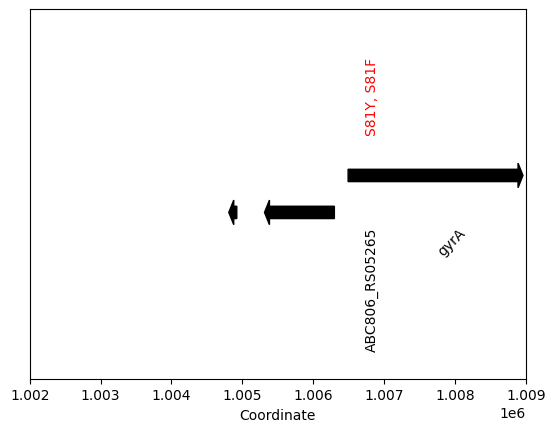

In [51]:
def plot_region(annotated_mutations, gff, 
               start_pos=1002000, end_pos=1009000,
               show_gene_names = False,
               show_locus_tags = False):
    arrow_head_length = (end_pos - start_pos)/100
    plt.xlim(start_pos, end_pos)
    plt.ylim(-3,3)
    gff['start'] = gff['start'].astype(int)
    gff['end'] = gff['end'].astype(int)
    gff_subset = gff[(gff['start']>=start_pos) & (gff['end']<=end_pos)]
    gff_subset['center'] = (gff_subset['end'] + gff_subset['start']) / 2
    gff_subset['length'] = abs( gff_subset['end'] - gff_subset['start'] )
    
    annotated_mutations_subset = annotated_mutations[(annotated_mutations['start']>=start_pos) 
        & (annotated_mutations['end']<=end_pos)]
    
    for i, row in gff_subset.iterrows():
        orientation = 1
        fiveprime_end = 'start'
        if row['strand'] == '-':
            orientation = -1
            fiveprime_end = 'end'
        plt.arrow(row[fiveprime_end], 0.3*orientation, orientation * row['length'],0, width=0.2, head_width = 0.4,
                  head_length=arrow_head_length,
                  length_includes_head = True, 
                    color='black',
                 )
        if show_gene_names:
            plt.text(row['center'], -1, 
                     s=row['gene'], 
                     rotation=45,
                    )

            
    for i, row in annotated_mutations_subset.iterrows():
        ABX = row['ABX']
        if row['AA change']: 
            mutation = row['AA change']
            textcol = 'red'
        else: 
            mutation = row['ref']+'-->'+row['alt'] + f'|{ABX}'
            textcol = 'gray'
        plt.text(row['start'], 1 ,s=mutation, rotation = 90, color=textcol)
        #print(ABX, mutation)
        if show_locus_tags:
            plt.text(row['start'], -2.5, 
                     s=row['locus_tag'], 
                     rotation=90,
                    )
    plt.yticks([])
    plt.xlabel('Coordinate')

plot_region(annotated_mutations, gff,
           show_gene_names=True,
           show_locus_tags=True)

In [25]:
annotated_mutations[(annotated_mutations.ABX=='CIP') & (~annotated_mutations.locus_tag.isnull())]

,chrom,start,end,ref,alt,qual,ABX,gene_start,gene_end,strand,gene,locus_tag,AA change
4799,NZ_CP155539.1,713637,713638,C,A,NaN,CIP,713480,714925,-,None,ABC806_RS03775,A430S
11188,NZ_CP155539.1,1006733,1006734,C,"A,T",NaN,CIP,1006493,1008961,+,gyrA,ABC806_RS05265,"S81Y, S81F"
17631,NZ_CP155539.1,1355418,1355419,G,"T,A,C",NaN,CIP,1353183,1355654,-,parC,ABC806_RS07030,"S79Y, S79F, S79C"


/tmp/ipykernel_1877/1857024956.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gff_subset['center'] = (gff_subset['end'] + gff_subset['start']) / 2
/tmp/ipykernel_1877/1857024956.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gff_subset['length'] = abs( gff_subset['end'] - gff_subset['start'] )


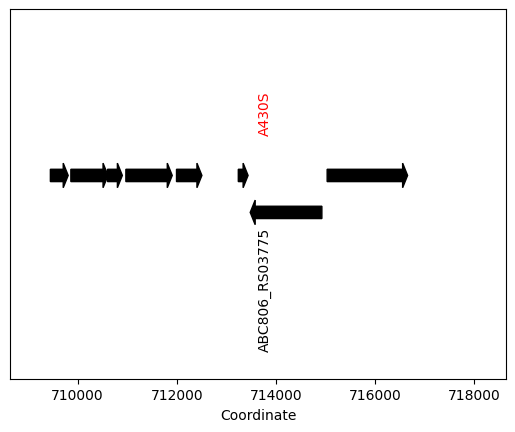

/tmp/ipykernel_1877/1857024956.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gff_subset['center'] = (gff_subset['end'] + gff_subset['start']) / 2
/tmp/ipykernel_1877/1857024956.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gff_subset['length'] = abs( gff_subset['end'] - gff_subset['start'] )


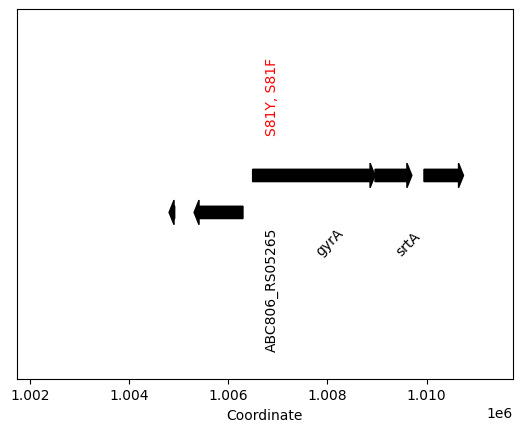

/tmp/ipykernel_1877/1857024956.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gff_subset['center'] = (gff_subset['end'] + gff_subset['start']) / 2
/tmp/ipykernel_1877/1857024956.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gff_subset['length'] = abs( gff_subset['end'] - gff_subset['start'] )


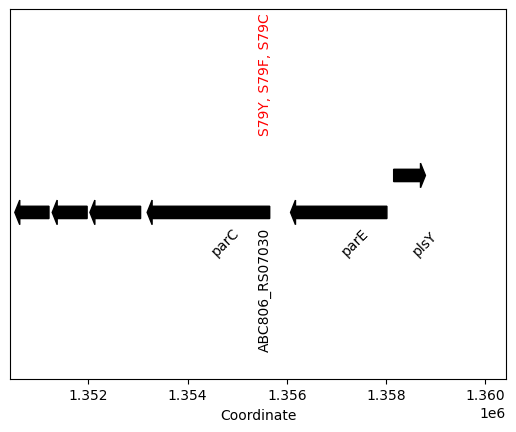

In [52]:
# size of region on each side of the mutation to check
flanking_region = 5000 

annot_mutations_CIP = annotated_mutations[(annotated_mutations.ABX=='CIP') & (~annotated_mutations.locus_tag.isnull())]
# go over each mutation, and plot the neighborhood. 
for i, row in annot_mutations_CIP.iterrows():
    locus = row['start']
    plot_region(annot_mutations_CIP, gff,
                start_pos = locus-flanking_region,
                end_pos = locus+flanking_region,
           show_gene_names=True,
               show_locus_tags=True)
    plt.show()



/tmp/ipykernel_1877/3451857250.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gff_subset['center'] = (gff_subset['end'] + gff_subset['start']) / 2
/tmp/ipykernel_1877/3451857250.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gff_subset['length'] = abs( gff_subset['end'] - gff_subset['start'] )


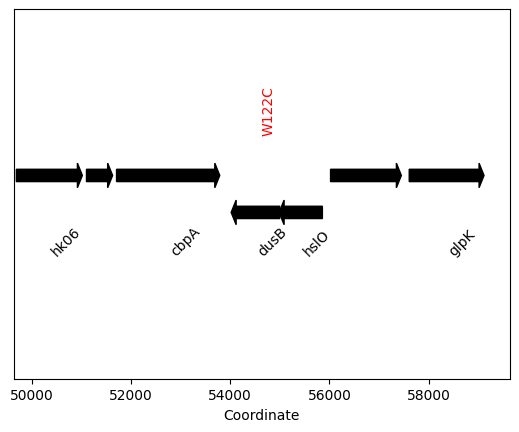

/tmp/ipykernel_1877/3451857250.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gff_subset['center'] = (gff_subset['end'] + gff_subset['start']) / 2
/tmp/ipykernel_1877/3451857250.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gff_subset['length'] = abs( gff_subset['end'] - gff_subset['start'] )


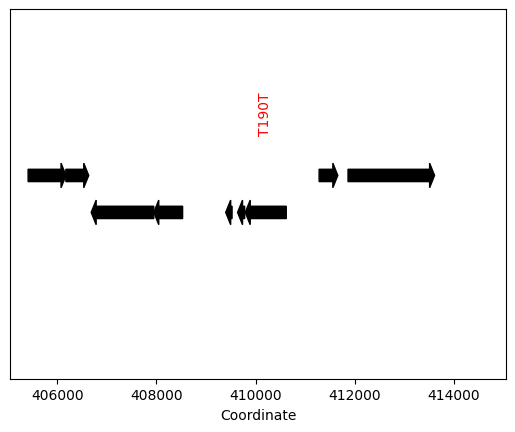

/tmp/ipykernel_1877/3451857250.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gff_subset['center'] = (gff_subset['end'] + gff_subset['start']) / 2
/tmp/ipykernel_1877/3451857250.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gff_subset['length'] = abs( gff_subset['end'] - gff_subset['start'] )


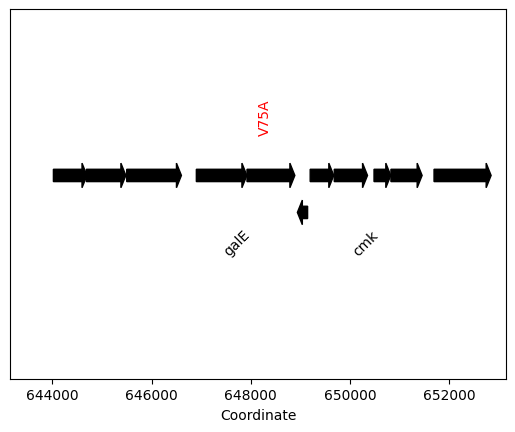

/tmp/ipykernel_1877/3451857250.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gff_subset['center'] = (gff_subset['end'] + gff_subset['start']) / 2
/tmp/ipykernel_1877/3451857250.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gff_subset['length'] = abs( gff_subset['end'] - gff_subset['start'] )


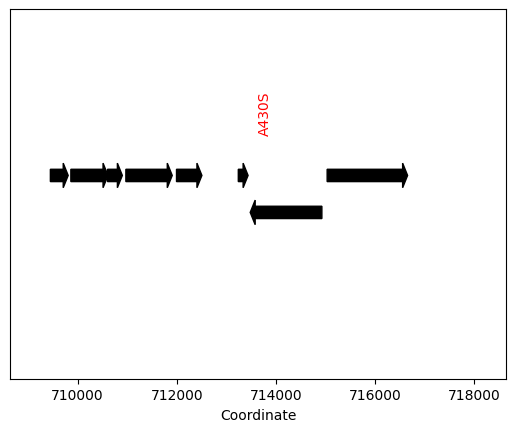

/tmp/ipykernel_1877/3451857250.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gff_subset['center'] = (gff_subset['end'] + gff_subset['start']) / 2
/tmp/ipykernel_1877/3451857250.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gff_subset['length'] = abs( gff_subset['end'] - gff_subset['start'] )


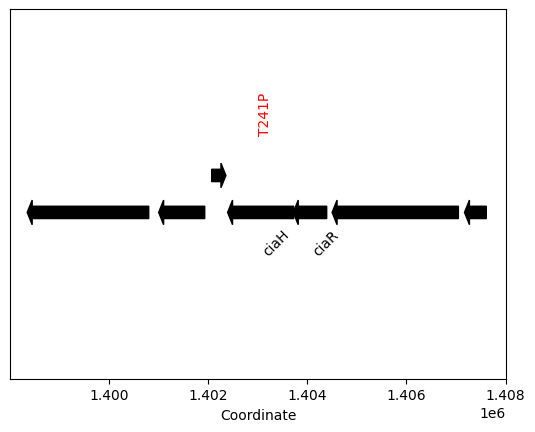

/tmp/ipykernel_1877/3451857250.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gff_subset['center'] = (gff_subset['end'] + gff_subset['start']) / 2
/tmp/ipykernel_1877/3451857250.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gff_subset['length'] = abs( gff_subset['end'] - gff_subset['start'] )


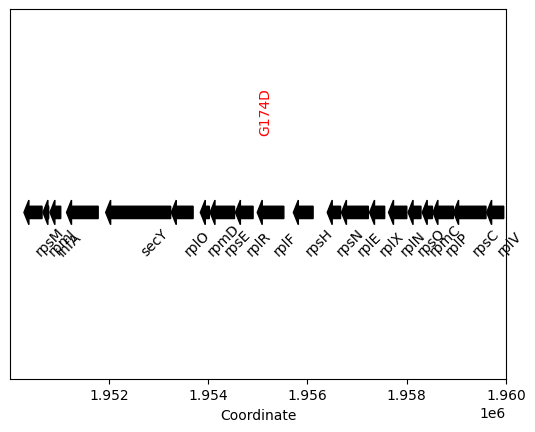

/tmp/ipykernel_1877/3451857250.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gff_subset['center'] = (gff_subset['end'] + gff_subset['start']) / 2
/tmp/ipykernel_1877/3451857250.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gff_subset['length'] = abs( gff_subset['end'] - gff_subset['start'] )


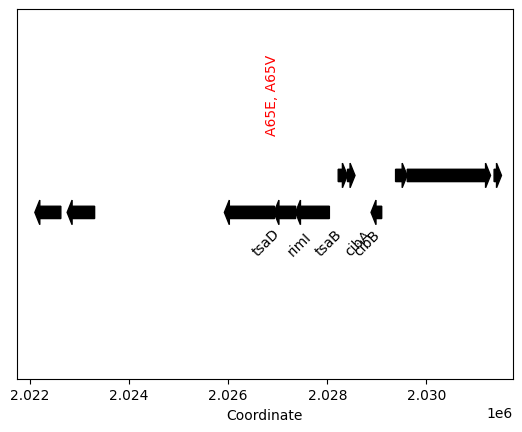

In [29]:
annot_mutations_KAN = annotated_mutations[(annotated_mutations.ABX=='KAN') & (~annotated_mutations.locus_tag.isnull())]
# go over each mutation, and plot the neighborhood. 
for i, row in annot_mutations_KAN.iterrows():
    locus = row['start']
    plot_region(annot_mutations_KAN, gff,
                start_pos = locus-flanking_region,
                end_pos = locus+flanking_region,
           show_gene_names=True)
    plt.show()


/tmp/ipykernel_1877/3451857250.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gff_subset['center'] = (gff_subset['end'] + gff_subset['start']) / 2
/tmp/ipykernel_1877/3451857250.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gff_subset['length'] = abs( gff_subset['end'] - gff_subset['start'] )


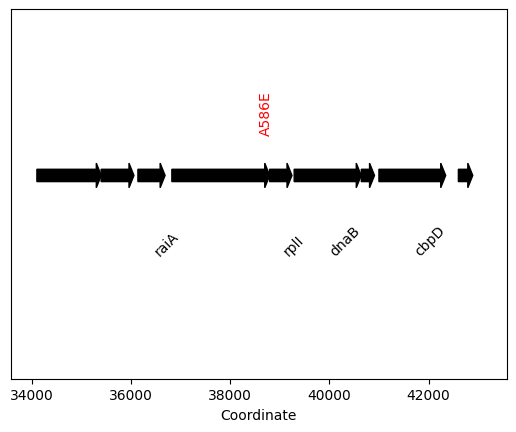

/tmp/ipykernel_1877/3451857250.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gff_subset['center'] = (gff_subset['end'] + gff_subset['start']) / 2
/tmp/ipykernel_1877/3451857250.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gff_subset['length'] = abs( gff_subset['end'] - gff_subset['start'] )


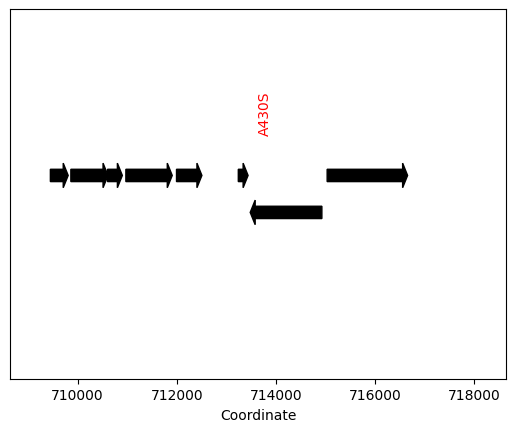

/tmp/ipykernel_1877/3451857250.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gff_subset['center'] = (gff_subset['end'] + gff_subset['start']) / 2
/tmp/ipykernel_1877/3451857250.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gff_subset['length'] = abs( gff_subset['end'] - gff_subset['start'] )


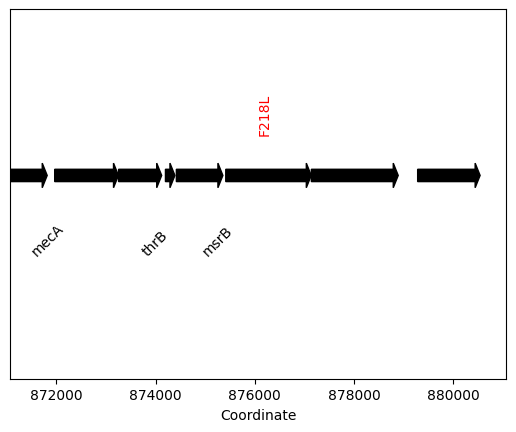

/tmp/ipykernel_1877/3451857250.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gff_subset['center'] = (gff_subset['end'] + gff_subset['start']) / 2
/tmp/ipykernel_1877/3451857250.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gff_subset['length'] = abs( gff_subset['end'] - gff_subset['start'] )


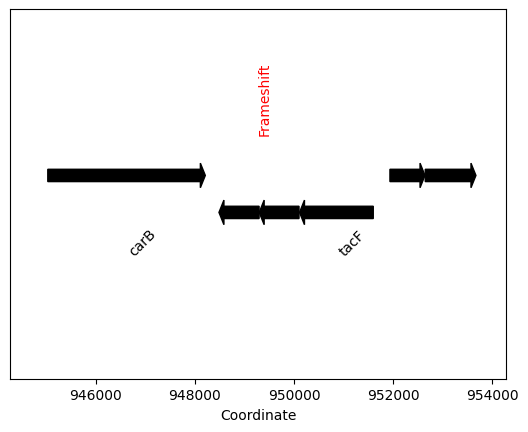

/tmp/ipykernel_1877/3451857250.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gff_subset['center'] = (gff_subset['end'] + gff_subset['start']) / 2
/tmp/ipykernel_1877/3451857250.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gff_subset['length'] = abs( gff_subset['end'] - gff_subset['start'] )


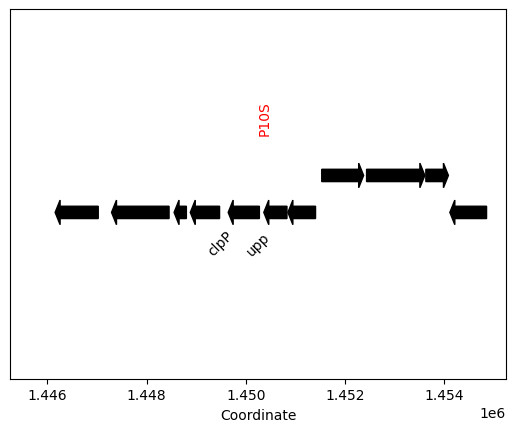

/tmp/ipykernel_1877/3451857250.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gff_subset['center'] = (gff_subset['end'] + gff_subset['start']) / 2
/tmp/ipykernel_1877/3451857250.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gff_subset['length'] = abs( gff_subset['end'] - gff_subset['start'] )


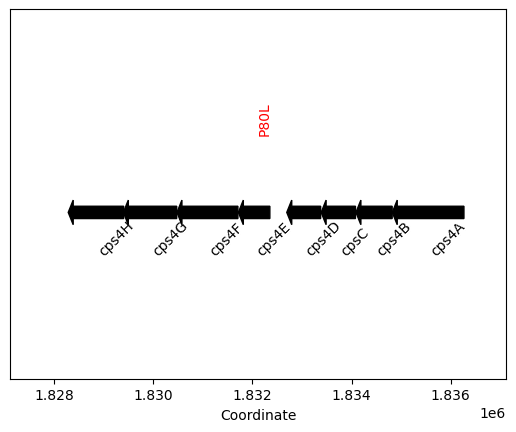

/tmp/ipykernel_1877/3451857250.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gff_subset['center'] = (gff_subset['end'] + gff_subset['start']) / 2
/tmp/ipykernel_1877/3451857250.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gff_subset['length'] = abs( gff_subset['end'] - gff_subset['start'] )


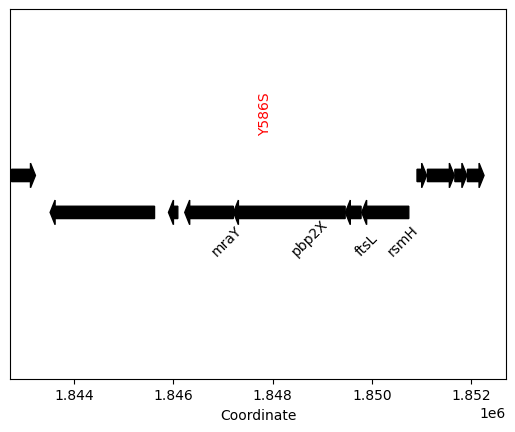

/tmp/ipykernel_1877/3451857250.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gff_subset['center'] = (gff_subset['end'] + gff_subset['start']) / 2
/tmp/ipykernel_1877/3451857250.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gff_subset['length'] = abs( gff_subset['end'] - gff_subset['start'] )


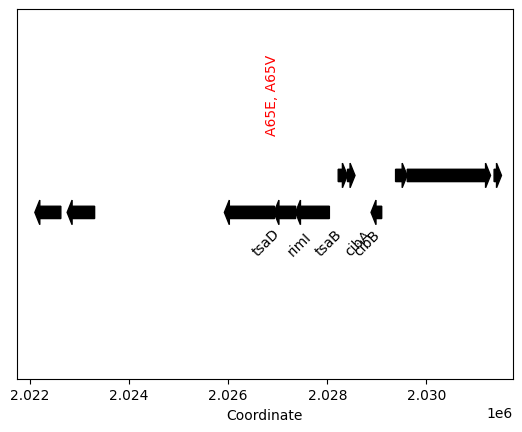

In [30]:
annot_mutations_PEN = annotated_mutations[(annotated_mutations.ABX=='PEN') & (~annotated_mutations.locus_tag.isnull())]
# go over each mutation, and plot the neighborhood. 
for i, row in annot_mutations_PEN.iterrows():
    locus = row['start']
    plot_region(annot_mutations_PEN, gff,
                start_pos = locus-flanking_region,
                end_pos = locus+flanking_region,
           show_gene_names=True)
    plt.show()


/tmp/ipykernel_1877/3451857250.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gff_subset['center'] = (gff_subset['end'] + gff_subset['start']) / 2
/tmp/ipykernel_1877/3451857250.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gff_subset['length'] = abs( gff_subset['end'] - gff_subset['start'] )


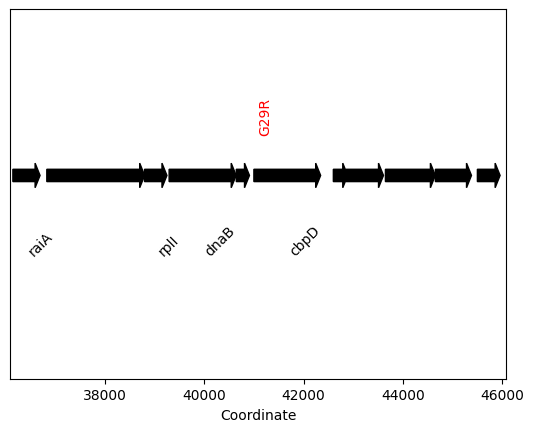

/tmp/ipykernel_1877/3451857250.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gff_subset['center'] = (gff_subset['end'] + gff_subset['start']) / 2
/tmp/ipykernel_1877/3451857250.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gff_subset['length'] = abs( gff_subset['end'] - gff_subset['start'] )


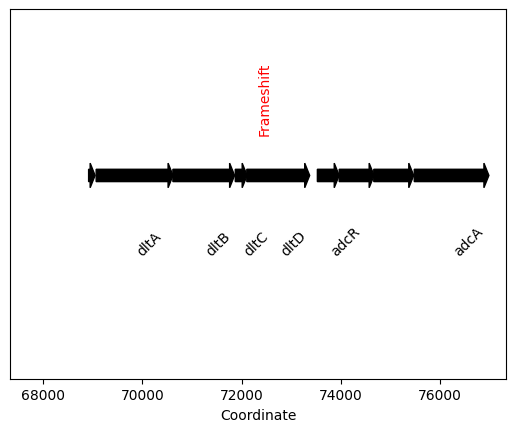

/tmp/ipykernel_1877/3451857250.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gff_subset['center'] = (gff_subset['end'] + gff_subset['start']) / 2
/tmp/ipykernel_1877/3451857250.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gff_subset['length'] = abs( gff_subset['end'] - gff_subset['start'] )


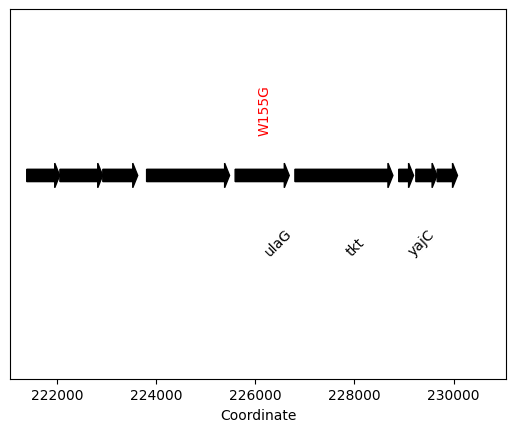

/tmp/ipykernel_1877/3451857250.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gff_subset['center'] = (gff_subset['end'] + gff_subset['start']) / 2
/tmp/ipykernel_1877/3451857250.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gff_subset['length'] = abs( gff_subset['end'] - gff_subset['start'] )


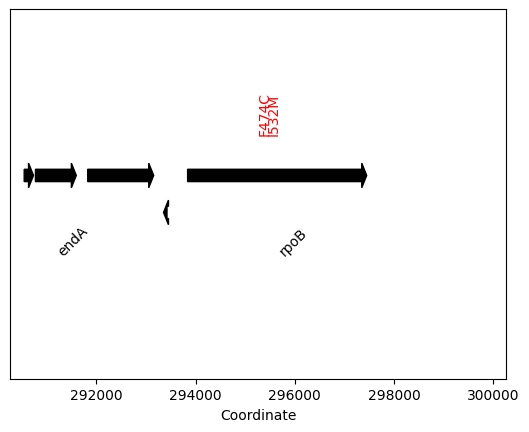

/tmp/ipykernel_1877/3451857250.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gff_subset['center'] = (gff_subset['end'] + gff_subset['start']) / 2
/tmp/ipykernel_1877/3451857250.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gff_subset['length'] = abs( gff_subset['end'] - gff_subset['start'] )


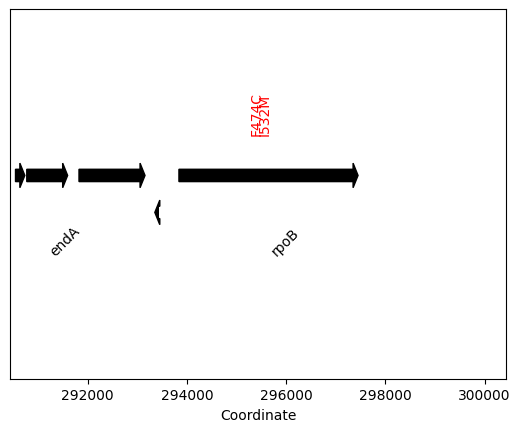

/tmp/ipykernel_1877/3451857250.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gff_subset['center'] = (gff_subset['end'] + gff_subset['start']) / 2
/tmp/ipykernel_1877/3451857250.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gff_subset['length'] = abs( gff_subset['end'] - gff_subset['start'] )


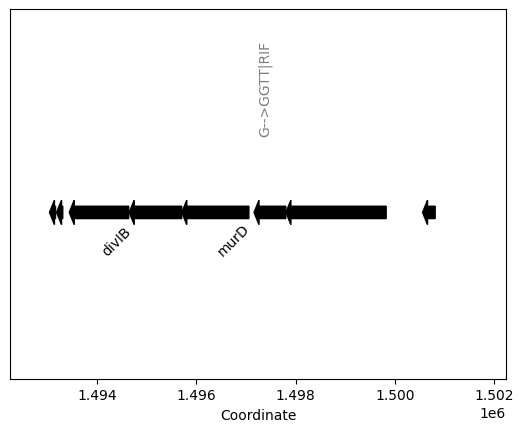

In [31]:
annot_mutations_RIF = annotated_mutations[(annotated_mutations.ABX=='RIF') & (~annotated_mutations.locus_tag.isnull())]
# go over each mutation, and plot the neighborhood. 
for i, row in annot_mutations_RIF.iterrows():
    locus = row['start']
    plot_region(annot_mutations_RIF, gff,
                start_pos = locus-flanking_region,
                end_pos = locus+flanking_region,
           show_gene_names=True)
    plt.show()


/tmp/ipykernel_1877/3451857250.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gff_subset['center'] = (gff_subset['end'] + gff_subset['start']) / 2
/tmp/ipykernel_1877/3451857250.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gff_subset['length'] = abs( gff_subset['end'] - gff_subset['start'] )


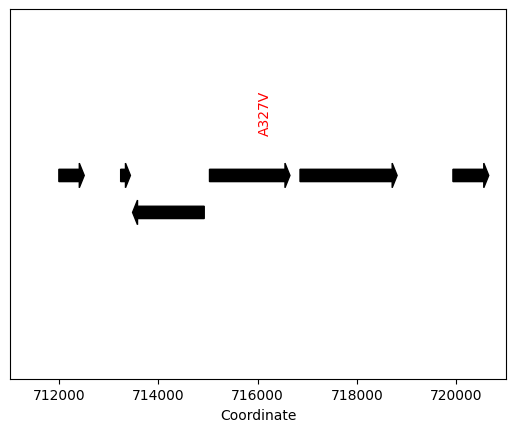

/tmp/ipykernel_1877/3451857250.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gff_subset['center'] = (gff_subset['end'] + gff_subset['start']) / 2
/tmp/ipykernel_1877/3451857250.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gff_subset['length'] = abs( gff_subset['end'] - gff_subset['start'] )


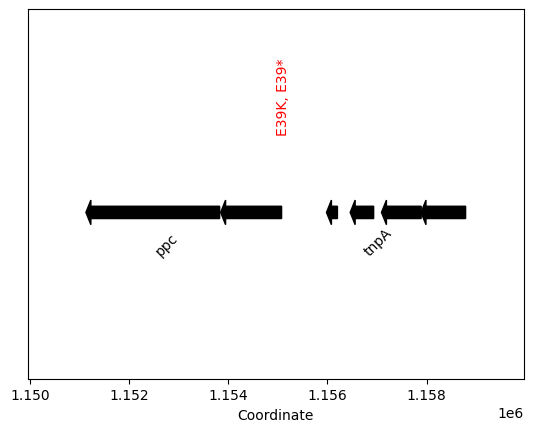

/tmp/ipykernel_1877/3451857250.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gff_subset['center'] = (gff_subset['end'] + gff_subset['start']) / 2
/tmp/ipykernel_1877/3451857250.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gff_subset['length'] = abs( gff_subset['end'] - gff_subset['start'] )


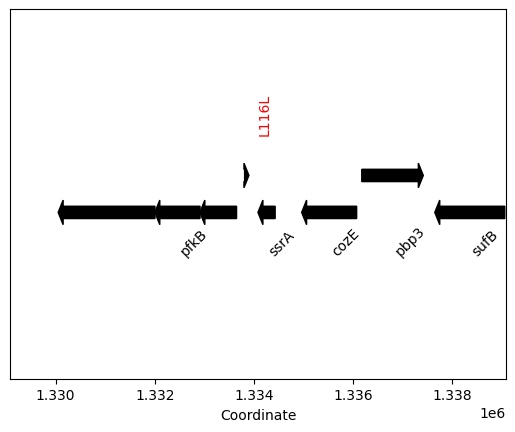

/tmp/ipykernel_1877/3451857250.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gff_subset['center'] = (gff_subset['end'] + gff_subset['start']) / 2
/tmp/ipykernel_1877/3451857250.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gff_subset['length'] = abs( gff_subset['end'] - gff_subset['start'] )


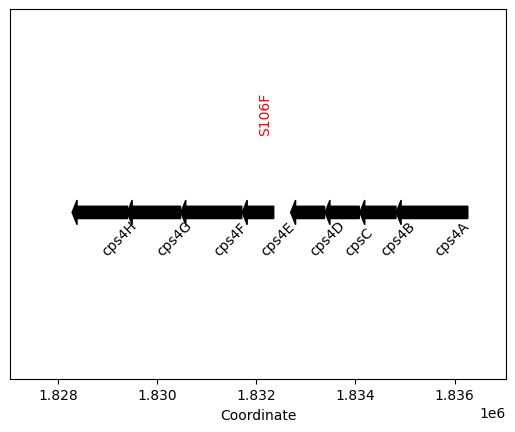

/tmp/ipykernel_1877/3451857250.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gff_subset['center'] = (gff_subset['end'] + gff_subset['start']) / 2
/tmp/ipykernel_1877/3451857250.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gff_subset['length'] = abs( gff_subset['end'] - gff_subset['start'] )


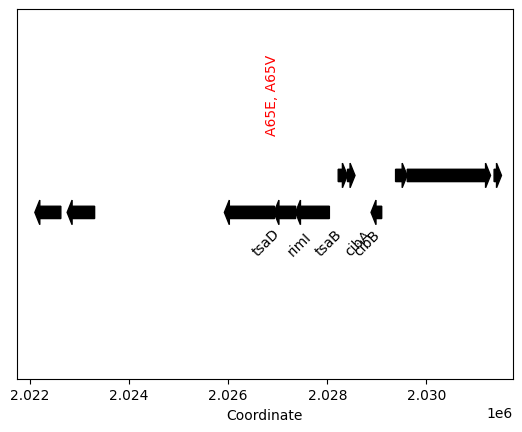

In [32]:
annot_mutations_VNC = annotated_mutations[(annotated_mutations.ABX=='VNC') & (~annotated_mutations.locus_tag.isnull())]
# go over each mutation, and plot the neighborhood. 
for i, row in annot_mutations_VNC.iterrows():
    locus = row['start']
    plot_region(annot_mutations_VNC, gff,
                start_pos = locus-flanking_region,
                end_pos = locus+flanking_region,
           show_gene_names=True)
    plt.show()